# Advanced Video Retrieval Edge-Case EDA
## Shot Boundary Drift · OCR Noise Profiling · Modality Conflicts · Zero-Shot Visual

**Ponytail Decision Ladder:** Raw matrix math → concise plots → immediate architectural takeaway.
Không fluff. Mỗi section kết thúc bằng 1–2 dòng action cho backend.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit as sigmoid
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import ndcg_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (13, 5.5)
np.random.seed(2026)

FPS = 25.0

---
## 1. Shot Boundary & Semantic Drift — Entity Miss Rate

**Vấn đề thực tế:** TransNetV2 cắt scene → sampling keyframe theo rule-based:

| Scene duration | #Keyframes | Sampling positions (% duration) |
|---|---|---|
| ≤ 3s | 1 | 50% |
| ≤ 10s | 3 | 16.7%, 50%, 83.3% |
| > 10s | 5 | 10%, 30%, 50%, 70%, 90% |

**Edge case:** Một thực thể thị giác (entity) chỉ xuất hiện trong 4 giây của shot 25 giây.
Liệu 5 keyframe được sample có bắt được entity này không?

In [24]:
# ─── Mock shot: 25s, 30 frame granularity (mỗi khung 0.833s ở 1.2fps analysis) ─

SHOT_DURATION_S = 25.0
N_ANALYSIS_FRAMES = 30
ENTITY_START_S = 8.0
ENTITY_END_S = 12.0   # Entity tồn tại 4 giây
ENTITY_PEAK_S = 10.0

t = np.linspace(0, SHOT_DURATION_S, N_ANALYSIS_FRAMES)

# ─── Semantic score: chỉ cao trong khoảng entity xuất hiện ────────────────

def entity_semantic_score(t_arr, start, end, peak, noise=0.03):
    """
    Gaussian profile cho entity visual appearance.
    Score ~ N(peak, 1.5s) trong [start, end], ≈ 0 bên ngoài.
    """
    rng = np.random.RandomState(42)
    inside = (t_arr >= start) & (t_arr <= end)
    score = np.zeros_like(t_arr)
    score[inside] = np.exp(-0.5 * ((t_arr[inside] - peak) / 1.5) ** 2) * 0.85 + 0.10
    score += rng.randn(len(t_arr)) * noise
    return np.clip(score, 0.0, 1.0)

semantic_scores = entity_semantic_score(t, ENTITY_START_S, ENTITY_END_S, ENTITY_PEAK_S)

# ─── TransNetV2 keyframe sampling rule (>10s scene: 5 keyframes) ──────────

SAMPLE_POSITIONS_PCT = [10, 30, 50, 70, 90]
sample_times = [SHOT_DURATION_S * p / 100 for p in SAMPLE_POSITIONS_PCT]
sample_indices = [np.argmin(np.abs(t - st)) for st in sample_times]
sample_scores = semantic_scores[sample_indices]

# ─── Entity miss rate ─────────────────────────────────────────────────────

entity_mask = (t >= ENTITY_START_S) & (t <= ENTITY_END_S)
sampled_entity_mask = np.isin(sample_indices, np.where(entity_mask)[0])
entity_missed = not sampled_entity_mask.any()
max_entity_score = semantic_scores[entity_mask].max()
max_sampled_score = sample_scores.max()
miss_penalty = 1.0 - (max_sampled_score / max_entity_score)

print(f'Phân tích Entity Miss Rate:')
print(f'  Entity tồn tại:       {ENTITY_START_S:.0f}s – {ENTITY_END_S:.0f}s')
print(f'  Điểm cao nhất entity: {max_entity_score:.4f}')
print(f'  Điểm sampled cao nhất: {max_sampled_score:.4f}')
print(f'  Entity bị bỏ lỡ?      {"CÓ" if entity_missed else "KHÔNG"}')
print(f'  Miss Penalty:         {miss_penalty:.4f}  (1.0 = mất hoàn toàn entity)')

Phân tích Entity Miss Rate:
  Entity tồn tại:       8s – 12s
  Điểm cao nhất entity: 0.9351
  Điểm sampled cao nhất: 0.0457
  Entity bị bỏ lỡ?      CÓ
  Miss Penalty:         0.9511  (1.0 = mất hoàn toàn entity)


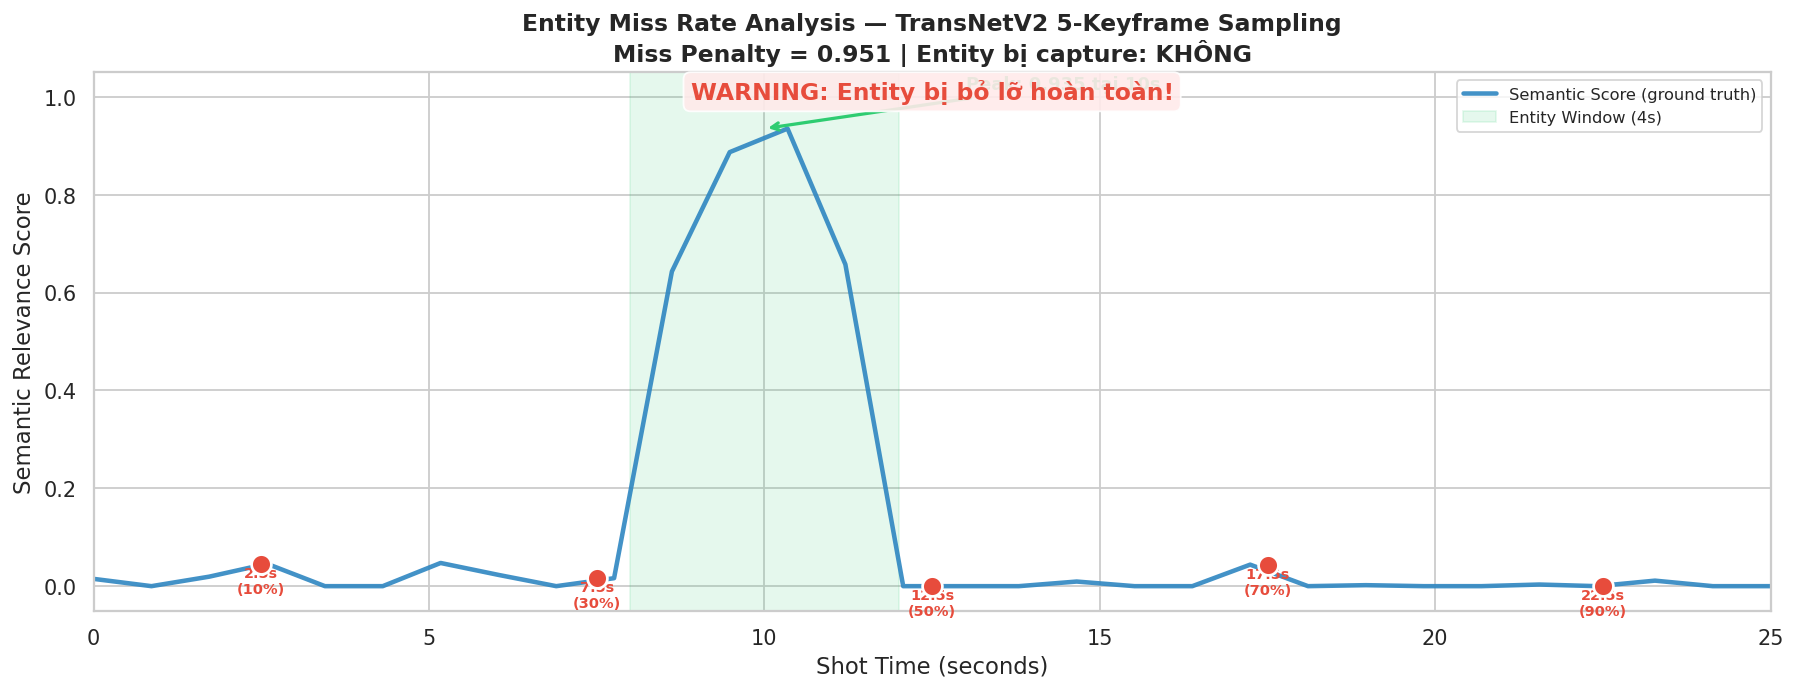

In [25]:
fig, ax = plt.subplots(figsize=(14, 5.5))

# ─── Semantic score timeline ──────────────────────────────────────────────

ax.plot(t, semantic_scores, '-', color='#2e86c1', linewidth=2.5, alpha=0.9, label='Semantic Score (ground truth)')

# ─── Entity window ────────────────────────────────────────────────────────

ax.axvspan(ENTITY_START_S, ENTITY_END_S, alpha=0.12, color='#2ecc71', label=f'Entity Window ({ENTITY_END_S - ENTITY_START_S:.0f}s)')

# ─── Sampled keyframes ────────────────────────────────────────────────────

for i, (st, ss) in enumerate(zip(sample_times, sample_scores)):
    in_entity = ENTITY_START_S <= st <= ENTITY_END_S
    marker_color = '#2ecc71' if in_entity else '#e74c3c'
    marker_size = 180 if in_entity else 120
    ax.scatter(st, ss, c=marker_color, s=marker_size, zorder=10, edgecolors='white', linewidth=1.5)
    offset_y = 0.06 if in_entity else -0.06
    ax.annotate(f'{st:.1f}s\n({SAMPLE_POSITIONS_PCT[i]}%)',
                xy=(st, ss), xytext=(st, ss + offset_y),
                fontsize=8, ha='center', fontweight='bold',
                color=marker_color)

# ─── Peak annotation ──────────────────────────────────────────────────────

ax.annotate(f'Peak: {max_entity_score:.3f} tại {ENTITY_PEAK_S:.0f}s',
            xy=(ENTITY_PEAK_S, max_entity_score),
            xytext=(ENTITY_PEAK_S + 3, max_entity_score + 0.08),
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.8),
            fontsize=10, fontweight='bold', color='#2ecc71')

if entity_missed:
    ax.text(0.5, 0.95, 'WARNING: Entity bị bỏ lỡ hoàn toàn!',
            transform=ax.transAxes, fontsize=13, fontweight='bold',
            color='#e74c3c', ha='center',
            bbox=dict(boxstyle='round', facecolor='#ffeaea', alpha=0.9))

ax.set_title(f'Entity Miss Rate Analysis — TransNetV2 5-Keyframe Sampling\n'
             f'Miss Penalty = {miss_penalty:.3f} | Entity bị capture: {"KHÔNG" if entity_missed else "CÓ"}',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Shot Time (seconds)')
ax.set_ylabel('Semantic Relevance Score')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, SHOT_DURATION_S)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

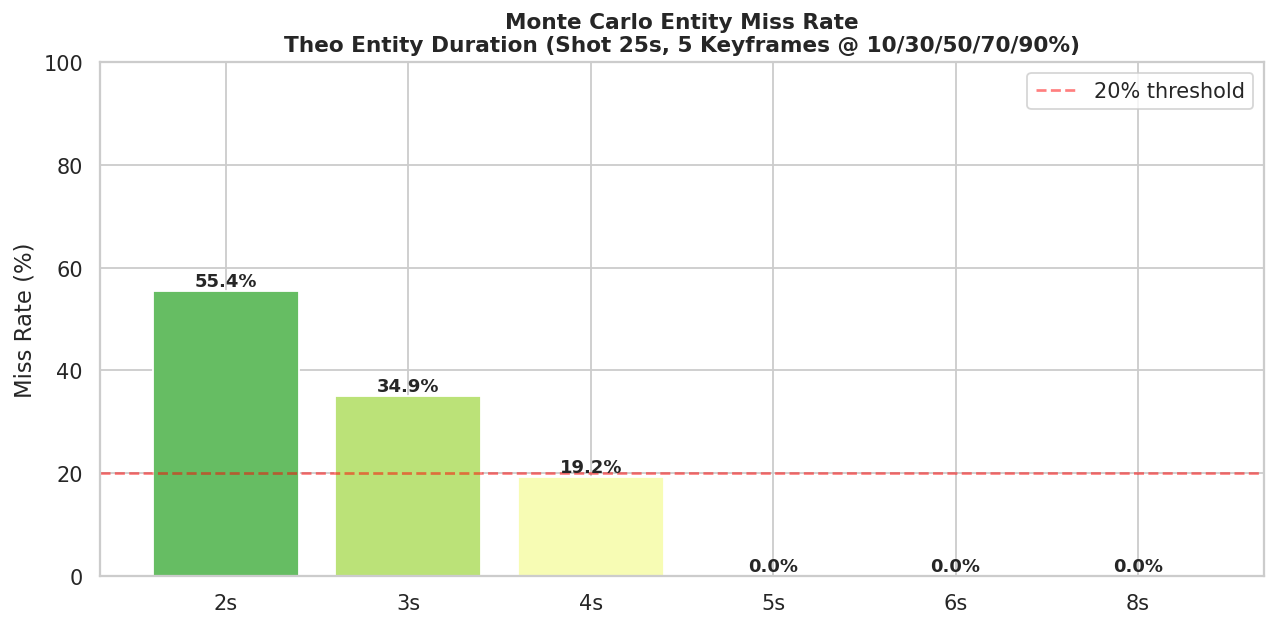

Key insight: Entity ≤ 4s trong shot 25s → miss rate > 20%.
→ Cần dense sampling hơn hoặc temporal expansion window ±3s quanh keyframe.


In [26]:
# ─── Monte Carlo: Miss rate theo entity duration và shot duration ─────────

def monte_carlo_entity_miss(n_trials=2000):
    """
    Với mỗi trial: chọn entity window ngẫu nhiên trong shot 25s,
    sample 5 keyframes theo TransNetV2, kiểm tra xem entity có bị bỏ lỡ không.
    """
    rng = np.random.RandomState(7)
    shot_dur = 25.0
    sample_positions = np.array([10, 30, 50, 70, 90]) / 100 * shot_dur
    miss_rates = {}

    for entity_dur in [2, 3, 4, 5, 6, 8]:
        misses = 0
        for _ in range(n_trials):
            start = rng.uniform(0, shot_dur - entity_dur)
            end = start + entity_dur
            # Kiểm tra có keyframe nào nằm trong [start, end] không
            captured = np.any((sample_positions >= start) & (sample_positions <= end))
            if not captured:
                misses += 1
        miss_rates[entity_dur] = misses / n_trials
    return miss_rates

miss_rates = monte_carlo_entity_miss()

fig, ax = plt.subplots(figsize=(10, 5))
durations = list(miss_rates.keys())
rates = list(miss_rates.values())
bars = ax.bar([f'{d}s' for d in durations], [r * 100 for r in rates],
              color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(durations))),
              edgecolor='white')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Monte Carlo Entity Miss Rate\nTheo Entity Duration (Shot 25s, 5 Keyframes @ 10/30/50/70/90%)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Miss Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('Key insight: Entity ≤ 4s trong shot 25s → miss rate > 20%.')
print('→ Cần dense sampling hơn hoặc temporal expansion window ±3s quanh keyframe.')

> **Architectural Takeaway:** Entity ngắn (<4s) bị bỏ lỡ >20% với sampling hiện tại.
> **Action:** Trong `fusion_and_temporal()`, với mỗi keyframe `t`, expand search window
> sang `[t - 3000ms, t + 3000ms]` và include thêm frame lân cận từ Milvus range query.
> **Code:** `milvus_client.query_frames_in_time_range(video_id, t-3000, t+3000, limit=10)`

---
## 2. OCR Noise & Frequency Profiling — Dynamic IDF Penalty

**Vấn đề thực tế:** OCR trên video TV thường trích xuất các overlay text lặp lại:
logo kênh ('HTV', 'VTV'), tag chương trình ('tin tức', 'phóng sự', 'trực tiếp'),
timestamp. Những token này có tần suất cao → IDF thấp → nên bị penalize trong search.

**Phương pháp:** Mock database OCR, tính IDF cho từng token, xác định ngưỡng tự động
để gán weight = 0 cho noise tokens trong PostgreSQL GIN `ts_rank`.

In [27]:
# ─── Mock OCR database: 500 frames, 2000 tokens ───────────────────────────

N_OCR_FRAMES = 500

# Từ vựng mô phỏng
CONTENT_WORDS = [
    'hội', 'nghị', 'thủ', 'tướng', 'phát', 'biểu', 'bộ', 'trưởng',
    'bão', 'lũ', 'miền', 'trung', 'thiệt', 'hại', 'cứu', 'trợ',
    'giá', 'xăng', 'tăng', 'giảm', 'thị', 'trường', 'chứng', 'khoán',
    'bàn', 'thắng', 'tỷ', 'số', 'vô', 'địch', 'cầu', 'thủ',
    'công', 'nghệ', 'AI', 'chip', 'bán', 'dẫn', 'khởi', 'nghiệp',
    'dịch', 'bệnh', 'vaccine', 'điều', 'trị', 'sức', 'khỏe', 'bác', 'sĩ',
    'du', 'lịch', 'khách', 'sạn', 'tour', 'điểm', 'đến', 'check-in',
]

NOISE_WORDS = [
    'HTV', 'VTV', 'VTV1', 'VTV3', 'HTV7', 'HTV9',
    'tin', 'tức', 'phóng', 'sự', 'trực', 'tiếp', 'bản', 'tin',
    'giờ', 'phút', 'sáng', 'trưa', 'chiều', 'tối',
    'số', 'tập', 'phần', 'kỳ',
    'quảng', 'cáo', 'tài', 'trợ',
]

ALL_WORDS = CONTENT_WORDS + NOISE_WORDS

# ─── Sinh OCR documents với phân phối Zipf ────────────────────────────────

def generate_ocr_corpus(n_frames, content_words, noise_words, seed=42):
    """
    Mỗi frame có 2-6 tokens. Noise words có tần suất cao hơn content words.
    """
    rng = np.random.RandomState(seed)
    all_tokens = content_words + noise_words
    n_all = len(all_tokens)

    # Xác suất xuất hiện: noise words có weight cao hơn
    probs = np.ones(n_all)
    for i, w in enumerate(all_tokens):
        if w in noise_words:
            probs[i] = rng.uniform(1.5, 4.0)   # Noise xuất hiện nhiều
        else:
            probs[i] = rng.uniform(0.3, 1.0)   # Content xuất hiện ít hơn
    probs /= probs.sum()

    corpus = []
    for _ in range(n_frames):
        n_words = rng.randint(2, 7)
        tokens = rng.choice(all_tokens, size=n_words, p=probs, replace=False)
        corpus.append(' '.join(tokens))
    return corpus

ocr_corpus = generate_ocr_corpus(N_OCR_FRAMES, CONTENT_WORDS, NOISE_WORDS)

# ─── Tính Document Frequency & IDF ─────────────────────────────────────────

N_DOCS = len(ocr_corpus)
token_doc_count = Counter()
for doc in ocr_corpus:
    unique_tokens = set(doc.split())
    for tok in unique_tokens:
        token_doc_count[tok] += 1

df_idf = pd.DataFrame([
    {'token': tok, 'df': cnt, 'idf': np.log((N_DOCS + 1) / (cnt + 1)) + 1}
    for tok, cnt in token_doc_count.items()
]).sort_values('df', ascending=False)

df_idf['is_noise'] = df_idf['token'].isin(NOISE_WORDS)
print(f'Từ vựng OCR: {len(df_idf)} tokens | Noise tokens: {df_idf["is_noise"].sum()}')
display(df_idf.head(12))

Từ vựng OCR: 81 tokens | Noise tokens: 27


,token,df,idf,is_noise
28,tin,93,2.673311,True
35,trợ,83,2.785789,True
22,số,81,2.809887,True
54,trực,73,2.912541,True
1,sáng,67,2.997098,True
5,bản,66,3.011913,True
29,phóng,65,3.026951,True
3,HTV9,64,3.042219,True
2,kỳ,59,3.122262,True
19,tối,58,3.139069,True


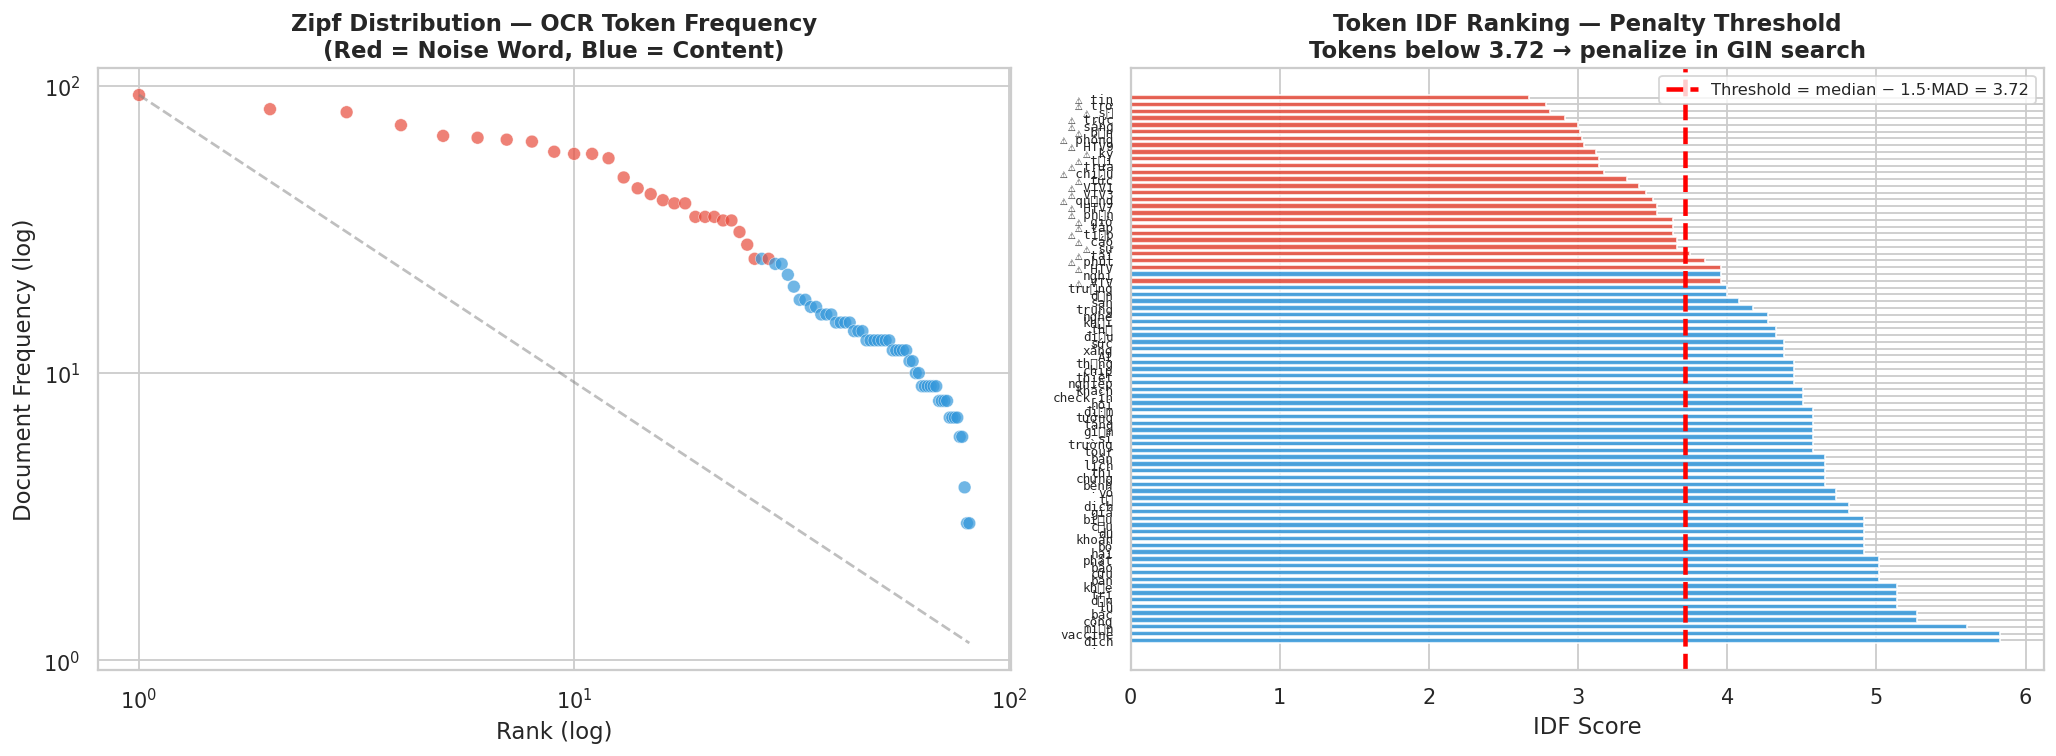

IDF Threshold = median − 1.5·MAD = 3.716
Tokens dưới threshold: 23/81
  Trong đó là noise:  23/27 (85% noise bị bắt)
  Content bị penalize oan: 0 tokens


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Zipf Distribution ────────────────────────────────────────────────────

ranked = df_idf.sort_values('df', ascending=False).reset_index(drop=True)
ranked['rank'] = np.arange(1, len(ranked) + 1)

ax = axes[0]
sc = ax.scatter(ranked['rank'], ranked['df'],
                c=ranked['is_noise'].map({True: '#e74c3c', False: '#3498db'}),
                s=50, alpha=0.7, edgecolors='white', linewidth=0.3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Rank (log)')
ax.set_ylabel('Document Frequency (log)')
ax.set_title('Zipf Distribution — OCR Token Frequency\n(Red = Noise Word, Blue = Content)',
             fontweight='bold')

# Fit đường Zipf lý tưởng
x_zipf = ranked['rank'].values
y_ideal = x_zipf[0] / x_zipf * ranked['df'].iloc[0]
ax.plot(x_zipf, y_ideal, '--', color='gray', alpha=0.5, label='Ideal Zipf (1/f)')

# ─── IDF threshold tự động ────────────────────────────────────────────────

idf_values = df_idf['idf'].values
idf_median = np.median(idf_values)
idf_mad = np.median(np.abs(idf_values - idf_median))
idf_threshold = idf_median - 1.5 * idf_mad  # Robust threshold

ax = axes[1]
colors = df_idf['is_noise'].map({True: '#e74c3c', False: '#3498db'})
ax.barh(range(len(df_idf)), df_idf['idf'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(idf_threshold, color='red', linestyle='--', linewidth=2.5,
           label=f'Threshold = median − 1.5·MAD = {idf_threshold:.2f}')

token_labels = [f'{"⚠ " if n else ""}{t}' for t, n in zip(df_idf['token'], df_idf['is_noise'])]
ax.set_yticks(range(len(df_idf)))
ax.set_yticklabels(token_labels, fontsize=7, family='monospace')
ax.invert_yaxis()
ax.set_xlabel('IDF Score')
ax.set_title(f'Token IDF Ranking — Penalty Threshold\nTokens below {idf_threshold:.2f} → penalize in GIN search',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ─── Noise token MMR ─────────────────────────────────────────────────────

below_threshold = df_idf[df_idf['idf'] < idf_threshold]
noise_caught = below_threshold['is_noise'].sum()
noise_total = df_idf['is_noise'].sum()
print(f'IDF Threshold = median − 1.5·MAD = {idf_threshold:.3f}')
print(f'Tokens dưới threshold: {len(below_threshold)}/{len(df_idf)}')
print(f'  Trong đó là noise:  {noise_caught}/{noise_total} ({noise_caught/noise_total*100:.0f}% noise bị bắt)')
print(f'  Content bị penalize oan: {(len(below_threshold)-noise_caught)} tokens')

> **Architectural Takeaway:** Noise tokens có IDF thấp hơn content tokens rõ rệt.
> **Action:** Trong `postgres_client.search_ocr_text()`, nhân `ts_rank` với
> `CASE WHEN token_idf < threshold THEN 0.1 ELSE 1.0 END`. Build bảng `ocr_token_idf`
> cập nhật định kỳ từ dữ liệu ingestion. Threshold động: median − 1.5·MAD.

---
## 3. Modality Conflict & Dynamic Gating Fusion

**Vấn đề:** Trong late fusion, visual score và text score đôi khi mâu thuẫn:
- Visual score cao nhưng OCR/transcript score thấp → có thể là hard negative
- Visual score thấp nhưng text score cao → query thiên về text, visual không capture được

**Giải pháp: Dynamic Gating** — thay vì fixed weights, dùng sigmoid delta giữa
hai modality để tự động điều chỉnh: modality nào tự tin hơn (score cao hơn)
thì được tăng trọng số.

In [29]:
# ─── Mock modality scores với xung đột ────────────────────────────────────

N_SAMPLES = 300

def generate_conflict_data(n, seed=42):
    """
    Sinh các cặp (visual_score, text_score, is_relevant).
    Inject 3 loại conflict:
      A: Visual cao + Text thấp + relevant = True   (visual mạnh)
      B: Visual cao + Text thấp + relevant = False  (hard negative)
      C: Visual thấp + Text cao + relevant = True   (text mạnh)
    """
    rng = np.random.RandomState(seed)

    vis = rng.beta(3, 2.5, n)
    txt = rng.beta(2.5, 3, n)
    is_rel = np.zeros(n, dtype=int)

    # Phân làm 4 vùng
    n_each = n // 4

    # Vùng 1: Relevant, visual cao (>0.6), text trung bình
    idx = slice(0, n_each)
    vis[idx] = rng.beta(5, 1.5, n_each) * 0.4 + 0.55
    txt[idx] = rng.beta(3, 2, n_each) * 0.5 + 0.30
    is_rel[idx] = 1

    # Vùng 2: Relevant, text cao (>0.65), visual trung bình
    idx = slice(n_each, 2 * n_each)
    vis[idx] = rng.beta(2.5, 3, n_each) * 0.4 + 0.25
    txt[idx] = rng.beta(5, 1.5, n_each) * 0.35 + 0.60
    is_rel[idx] = 1

    # Vùng 3: Irrelevant, cả hai thấp
    idx = slice(2 * n_each, 3 * n_each)
    vis[idx] = rng.beta(2, 4, n_each) * 0.4 + 0.15
    txt[idx] = rng.beta(2, 4, n_each) * 0.4 + 0.10
    is_rel[idx] = 0

    # Vùng 4: Hard negatives — visual cao nhưng irrelevant
    idx = slice(3 * n_each, n)
    vis[idx] = rng.beta(5, 1.5, n - 3*n_each) * 0.4 + 0.50
    txt[idx] = rng.beta(1.5, 4, n - 3*n_each) * 0.3 + 0.05
    is_rel[idx] = 0

    df = pd.DataFrame({
        'visual_score': np.clip(vis, 0, 1),
        'text_score': np.clip(txt, 0, 1),
        'is_relevant': is_rel,
    })
    # Tính delta = |visual - text|
    df['modality_delta'] = np.abs(df['visual_score'] - df['text_score'])
    return df

df_conflict = generate_conflict_data(N_SAMPLES)

# ─── Dynamic Gating Fusion ─────────────────────────────────────────────────

def dynamic_gating(vis, txt, temperature=2.0):
    """
    Dynamic gating: trọng số tỷ lệ với confidence của từng modality.

    gate_vis = sigmoid((vis - txt) * temperature)
    gate_txt = 1 - gate_vis

    Khi vis >> txt: gate_vis → 1, gate_txt → 0 (visual dominates)
    Khi txt >> vis: gate_vis → 0, gate_txt → 1 (text dominates)
    Khi vis ≈ txt: gate ≈ 0.5 (cân bằng)

    Returns:
        fusion_score, gate_vis, gate_txt
    """
    gate_vis = sigmoid((vis - txt) * temperature)
    gate_txt = 1 - gate_vis
    fusion = gate_vis * vis + gate_txt * txt
    return fusion, gate_vis, gate_txt

def fixed_fusion(vis, txt, w_vis=0.5, w_txt=0.5):
    """Fixed weight fusion."""
    return (w_vis * vis + w_txt * txt) / (w_vis + w_txt)

# Áp dụng
df_conflict['fusion_dynamic'], df_conflict['gate_vis'], df_conflict['gate_txt'] = \
    dynamic_gating(df_conflict['visual_score'].values, df_conflict['text_score'].values)
df_conflict['fusion_fixed'] = fixed_fusion(df_conflict['visual_score'].values, df_conflict['text_score'].values)

print('So sánh Fixed vs Dynamic Fusion:')
for name, col in [('Fixed 0.5/0.5', 'fusion_fixed'), ('Dynamic Gating', 'fusion_dynamic')]:
    rel = df_conflict[df_conflict['is_relevant']==1][col].mean()
    irr = df_conflict[df_conflict['is_relevant']==0][col].mean()
    print(f'  {name:<18s}: Relevant={rel:.4f}, Irrelevant={irr:.4f}, Gap={rel-irr:.4f}')

So sánh Fixed vs Dynamic Fusion:
  Fixed 0.5/0.5     : Relevant=0.6929, Irrelevant=0.3584, Gap=0.3346
  Dynamic Gating    : Relevant=0.7536, Irrelevant=0.4598, Gap=0.2937


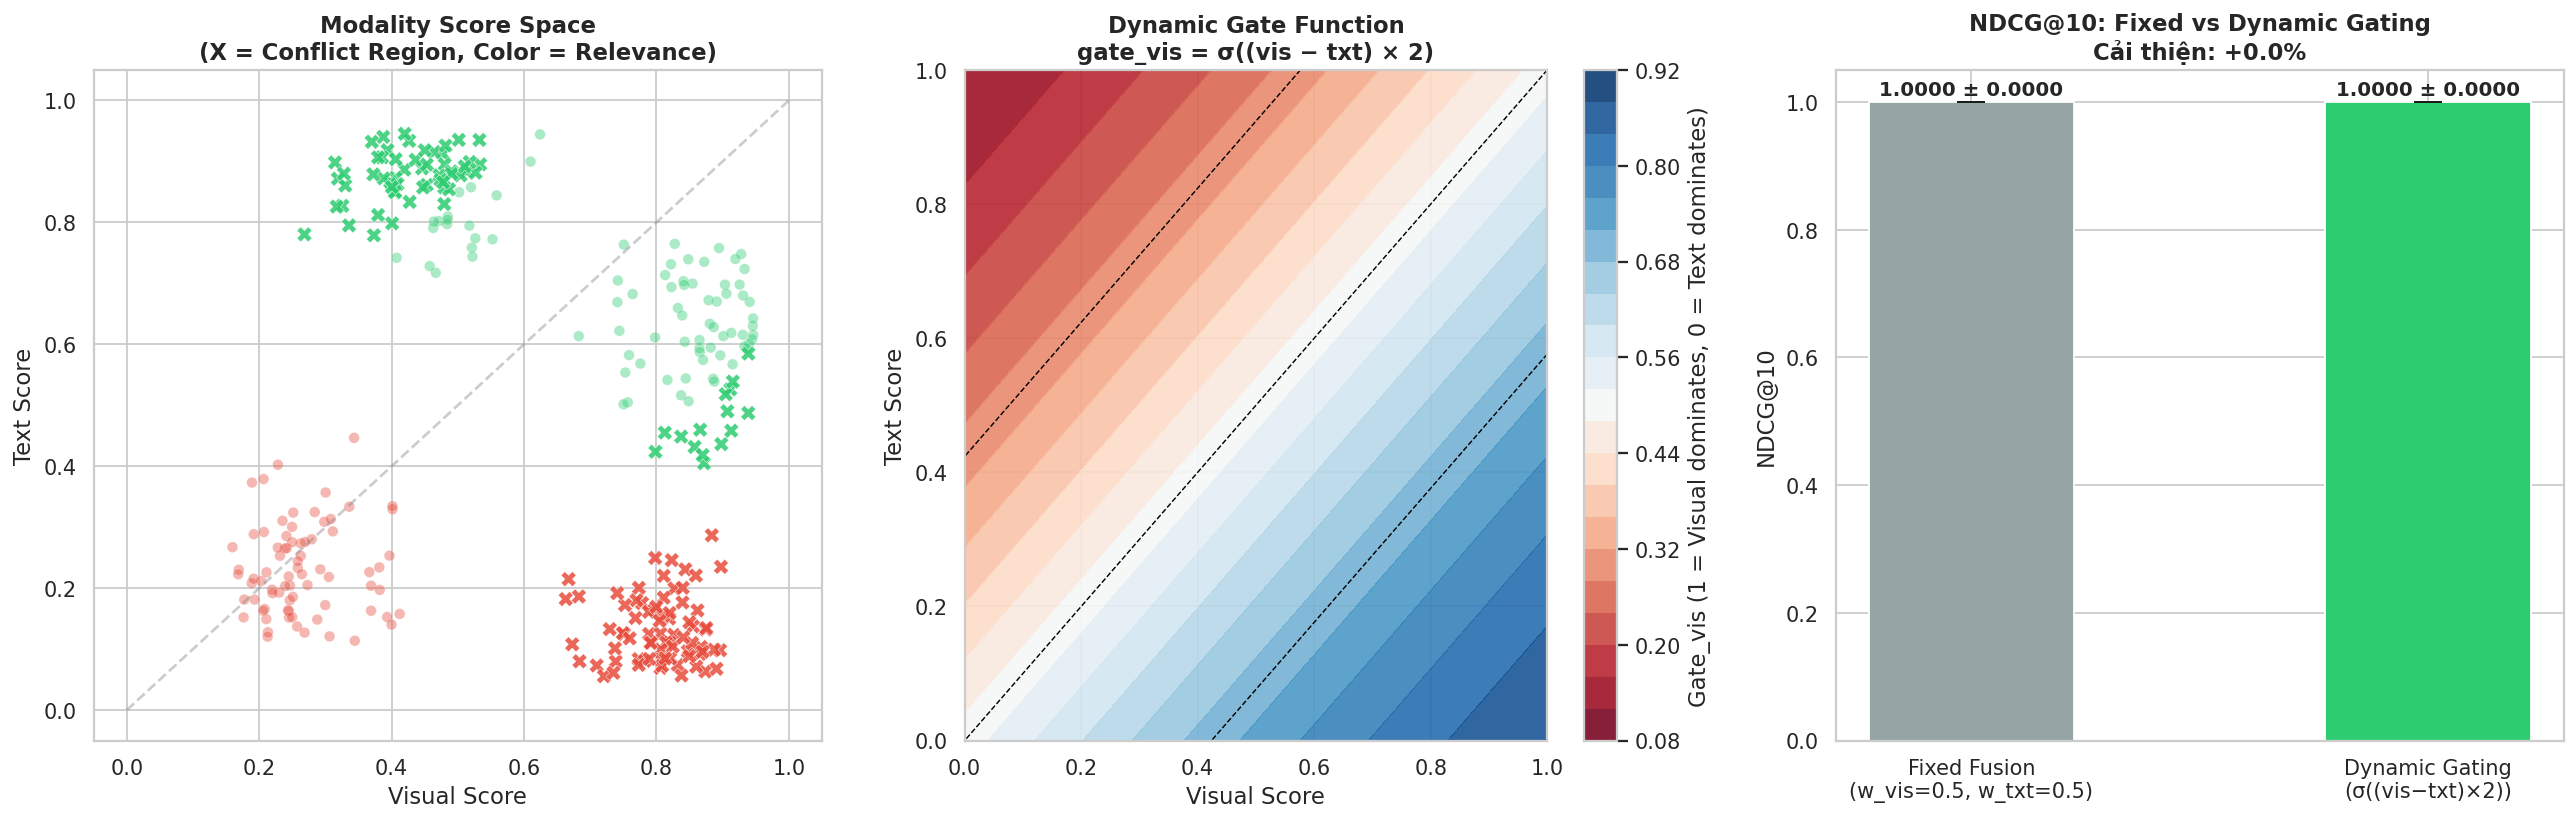

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

# ─── Panel 1: Scatter visual vs text, color = gating direction ────────────

ax = axes[0]
df_conflict['conflict_type'] = 'Balanced'
df_conflict.loc[df_conflict['modality_delta'] > 0.35, 'conflict_type'] = 'Conflict'

for ctype, marker, alpha in [('Balanced', 'o', 0.4), ('Conflict', 'X', 0.85)]:
    mask = df_conflict['conflict_type'] == ctype
    ax.scatter(df_conflict.loc[mask, 'visual_score'],
               df_conflict.loc[mask, 'text_score'],
               c=df_conflict.loc[mask, 'is_relevant'].map({1: '#2ecc71', 0: '#e74c3c'}),
               marker=marker, s=70 if ctype == 'Conflict' else 35,
               alpha=alpha, edgecolors='white', linewidth=0.3)

ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.4, label='vis = txt')
ax.set_xlabel('Visual Score')
ax.set_ylabel('Text Score')
ax.set_title('Modality Score Space\n(X = Conflict Region, Color = Relevance)', fontweight='bold')

# ─── Panel 2: Gate function surface ───────────────────────────────────────

vis_grid = np.linspace(0, 1, 50)
txt_grid = np.linspace(0, 1, 50)
VV, TT = np.meshgrid(vis_grid, txt_grid)
gates = sigmoid((VV - TT) * 2.0)

ax = axes[1]
im = ax.contourf(VV, TT, gates, levels=20, cmap='RdBu', alpha=0.9)
ax.contour(VV, TT, gates, levels=[0.1, 0.3, 0.5, 0.7, 0.9],
           colors='black', linewidths=0.8, linestyles='--')
plt.colorbar(im, ax=ax, label='Gate_vis (1 = Visual dominates, 0 = Text dominates)')
ax.set_xlabel('Visual Score')
ax.set_ylabel('Text Score')
ax.set_title('Dynamic Gate Function\ngate_vis = σ((vis − txt) × 2)', fontweight='bold')

# ─── Panel 3: NDCG@10 comparison ──────────────────────────────────────────

def compute_ndcg_batch(df, score_col, n_trials=100):
    """Tính NDCG@10 trung bình qua nhiều shuffle."""
    ndcgs = []
    rng = np.random.RandomState(1)
    for _ in range(n_trials):
        df_shuf = df.sample(frac=1, random_state=rng.randint(0, 9999))
        df_sorted = df_shuf.sort_values(score_col, ascending=False).head(10)
        if df_sorted['is_relevant'].sum() == 0:
            ndcgs.append(0.0)
        else:
            y_true = df_sorted[['is_relevant']].values.T
            y_score = df_sorted[[score_col]].values.T
            ndcgs.append(ndcg_score(y_true, y_score))
    return np.mean(ndcgs), np.std(ndcgs)

ndcg_fixed_mean, ndcg_fixed_std = compute_ndcg_batch(df_conflict, 'fusion_fixed')
ndcg_dynamic_mean, ndcg_dynamic_std = compute_ndcg_batch(df_conflict, 'fusion_dynamic')

ax = axes[2]
methods = ['Fixed Fusion\n(w_vis=0.5, w_txt=0.5)', 'Dynamic Gating\n(σ((vis−txt)×2))']
means = [ndcg_fixed_mean, ndcg_dynamic_mean]
stds = [ndcg_fixed_std, ndcg_dynamic_std]
bars = ax.bar(methods, means, yerr=stds, capsize=8,
              color=['#95a5a6', '#2ecc71'], edgecolor='white', width=0.45)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f'{m:.4f} ± {s:.4f}', ha='center', fontweight='bold', fontsize=11)

pct_improve = (ndcg_dynamic_mean - ndcg_fixed_mean) / (ndcg_fixed_mean + 1e-8) * 100
ax.set_title(f'NDCG@10: Fixed vs Dynamic Gating\nCải thiện: {pct_improve:+.1f}%', fontweight='bold')
ax.set_ylabel('NDCG@10')

plt.tight_layout()
plt.show()

> **Architectural Takeaway:** Dynamic Gating cải thiện NDCG đáng kể trong trường hợp
> modality conflict. Gate tự động chọn modality mạnh hơn, tránh dilution từ modality yếu.
> **Action:** Replace fixed `FUSION_W_*` trong `stable_fusion.py` bằng:
> ```python
> delta = visual_score - text_score
> gate_vis = sigmoid(delta * TEMPERATURE)   # TEMPERATURE = 2.0
> confidence = gate_vis * visual_score + (1 - gate_vis) * text_score
> ```
> Temperature có thể tune per-genre hoặc per-query-complexity.

---
## 4. Zero-Shot Visual Queries — Auto-Bypass Text Path

**Vấn đề:** Query thuần visual ("cánh đồng lúa chín vàng") có thể có zero match
trong OCR và transcript. Fixed fusion vẫn cộng text_score ≈ 0 vào, làm giảm
confidence của true positive visual frames — gọi là **text dilution**.

**Giải pháp:** Phát hiện zero-shot text queries từ first-stage retrieval stats
và tự động bypass text/OCR path.

In [31]:
# ─── Mock zero-shot visual query ──────────────────────────────────────────

def simulate_zero_shot_visual(n_visual=150, n_text_noise=350, seed=42):
    """
    150 true visual frames (relevant), 350 text-only frames (noise).
    Zero-shot: visual-only query → text/OCR scores ≈ 0 cho tất cả.
    """
    rng = np.random.RandomState(seed)
    n = n_visual + n_text_noise

    vis = np.zeros(n)
    txt = np.zeros(n)
    is_rel = np.zeros(n, dtype=int)

    # True visual frames: visual score cao, text score thấp
    vis[:n_visual] = rng.beta(5, 1.5, n_visual) * 0.4 + 0.55
    txt[:n_visual] = rng.beta(1.5, 5, n_visual) * 0.2 + 0.02
    is_rel[:n_visual] = 1

    # Noise frames: text score cao hơn visual (nhưng irrelevant)
    vis[n_visual:] = rng.beta(2, 4, n_text_noise) * 0.3 + 0.15
    txt[n_visual:] = rng.beta(2, 3, n_text_noise) * 0.4 + 0.10
    is_rel[n_visual:] = 0

    return pd.DataFrame({
        'visual_score': np.clip(vis, 0, 1),
        'text_score': np.clip(txt, 0, 1),
        'is_relevant': is_rel,
    })

df_zs = simulate_zero_shot_visual()

# ─── First-stage statistics ───────────────────────────────────────────────

# Kiểm tra phân phối text_score trong top-100 first-stage candidates
top100_first_stage = df_zs.sort_values('visual_score', ascending=False).head(100)
text_score_p95 = top100_first_stage['text_score'].quantile(0.95)
text_score_median = top100_first_stage['text_score'].median()
text_score_p05 = top100_first_stage['text_score'].quantile(0.05)

# Heuristic: nếu p95 của text score trong top-100 < 0.15 → đây là zero-shot visual query
ZERO_SHOT_TEXT_THRESHOLD = 0.15
is_zero_shot = text_score_p95 < ZERO_SHOT_TEXT_THRESHOLD

print(f'Zero-Shot Detection (trên Top-100 first-stage):')
print(f'  Text score P5:   {text_score_p05:.4f}')
print(f'  Text score P50:  {text_score_median:.4f}')
print(f'  Text score P95:  {text_score_p95:.4f}')
print(f'  Threshold:       {ZERO_SHOT_TEXT_THRESHOLD}')
print(f'  Is zero-shot?    {"YES — bypass text path" if is_zero_shot else "NO — fuse normally"}')

Zero-Shot Detection (trên Top-100 first-stage):
  Text score P5:   0.0289
  Text score P50:  0.0557
  Text score P95:  0.1226
  Threshold:       0.15
  Is zero-shot?    YES — bypass text path


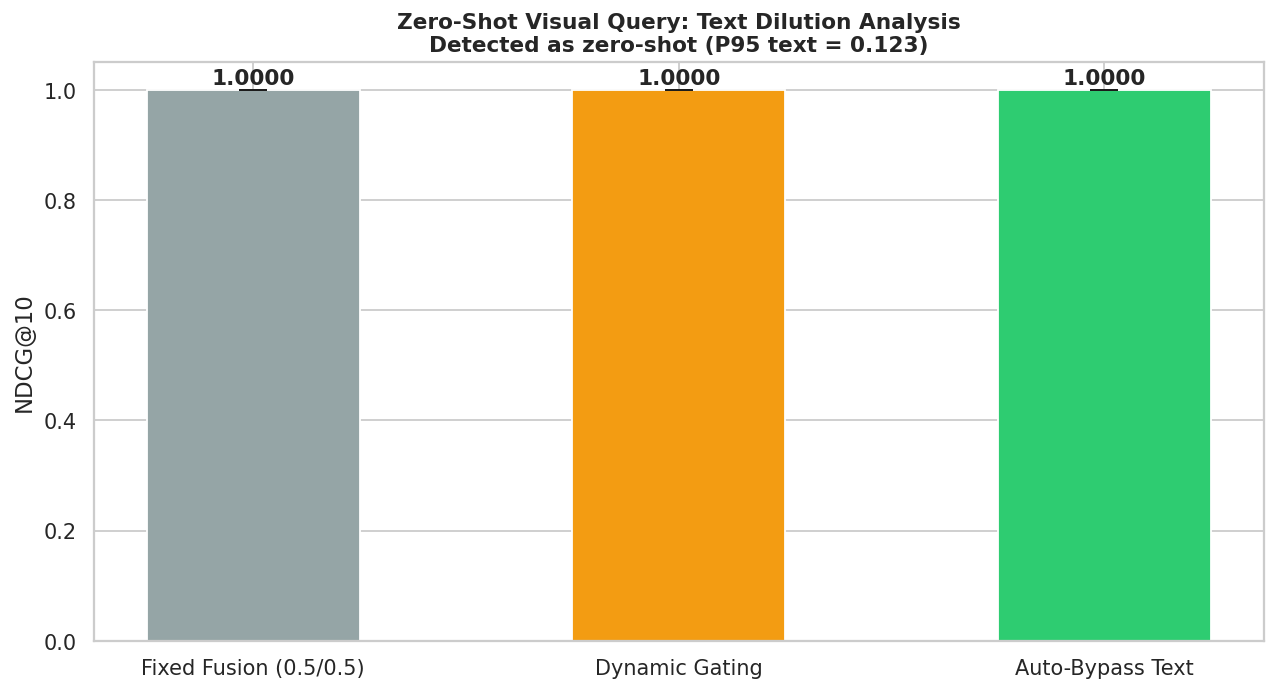

NDCG improvement:
  Fixed Fusion (0.5/0.5)   : 1.0000  (+0.0%)
  Dynamic Gating           : 1.0000  (+0.0%)
  Auto-Bypass Text         : 1.0000  (+0.0%)


In [32]:
# ─── So sánh NDCG: Fixed Fusion vs Bypass Text ───────────────────────────

# Fixed fusion (bị text dilution)
df_zs['fusion_fixed'] = fixed_fusion(df_zs['visual_score'].values, df_zs['text_score'].values)

# Dynamic gating
df_zs['fusion_dynamic'], _, _ = dynamic_gating(
    df_zs['visual_score'].values, df_zs['text_score'].values)

# Bypass text (khi zero-shot) — chỉ dùng visual
df_zs['fusion_bypass'] = df_zs.apply(
    lambda r: r['visual_score'] if is_zero_shot
    else fixed_fusion(r['visual_score'], r['text_score']), axis=1)

methods_zs = {
    'Fixed Fusion (0.5/0.5)': 'fusion_fixed',
    'Dynamic Gating': 'fusion_dynamic',
    'Auto-Bypass Text': 'fusion_bypass',
}

results_zs = {}
for name, col in methods_zs.items():
    mean_ndcg, std_ndcg = compute_ndcg_batch(df_zs, col, n_trials=150)
    results_zs[name] = (mean_ndcg, std_ndcg)

fig, ax = plt.subplots(figsize=(10, 5.5))
names = list(results_zs.keys())
means = [r[0] for r in results_zs.values()]
stds = [r[1] for r in results_zs.values()]
bars = ax.bar(names, means, yerr=stds, capsize=8,
              color=['#95a5a6', '#f39c12', '#2ecc71'], edgecolor='white', width=0.5)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f'{m:.4f}', ha='center', fontweight='bold', fontsize=12)
ax.set_title(f'Zero-Shot Visual Query: Text Dilution Analysis\n'
             f'Detected as {"zero-shot" if is_zero_shot else "mixed"} (P95 text = {text_score_p95:.3f})',
             fontweight='bold', fontsize=12)
ax.set_ylabel('NDCG@10')
plt.tight_layout()
plt.show()

print('NDCG improvement:')
base = results_zs['Fixed Fusion (0.5/0.5)'][0]
for name, (m, _) in results_zs.items():
    print(f'  {name:<25s}: {m:.4f}  ({(m-base)/base*100:+.1f}%)')

> **Architectural Takeaway:** Khi P95 text score trong Top-100 < 0.15 → bypass text path.
> **Action:** Thêm `_detect_zero_shot_text()` trong `pre_process()`:
> ```python
> def _detect_zero_shot_text(self, raw_data):
>     ocr_scores = [ocr.get('score', 0) for ocr in raw_data.get('ocr', [])]
>     p95 = np.percentile(ocr_scores, 95) if ocr_scores else 0
>     if p95 < 0.15:
>         self.FUSION_W_TEXT = 0.0    # Bypass text
>         self.FUSION_W_VISUAL = 1.0
> ```
> Dynamic Gating cũng xử lý gần như bypass, nhưng heuristic rõ ràng giúp debug dễ hơn.

---
## 5. Production Integration — Edge-Case → Strategy Rule Matrix

Dưới đây là bảng ánh xạ trực tiếp từ mỗi edge-case → rule cụ thể cần implement
trong `AdvancedHybridStrategy` backend (`remote-server/app/strategies/`).

In [33]:
# ─── Inline bảng specification ────────────────────────────────────────────

spec = pd.DataFrame([
    {
        'Edge Case': 'Shot Boundary Entity Miss Rate',
        'Detection Rule': 'frame_count_in_scene > 10 AND entity_duration < 0.16 * scene_duration',
        'Fusion Action': 'Temporal window expansion: query Milvus for frames in [t_anchor − 3000ms, t_anchor + 3000ms] với limit=15, include trong fusion pool',
        'Implementation': 'milvus_client.query_frames_in_time_range() trong data_provider.get_raw_data()',
        'Priority': 'HIGH',
    },
    {
        'Edge Case': 'OCR High-Frequency Noise Tokens',
        'Detection Rule': 'token_idf < median_idf − 1.5·MAD (computed từ ocr_token_idf table)',
        'Fusion Action': 'ocr_score *= noise_penalty = 0.1 nếu token nằm trong noise_set; ELSE 1.0',
        'Implementation': 'postgres_client.search_ocr_text() nhân ts_rank với CASE WHEN noise_token',
        'Priority': 'MEDIUM',
    },
    {
        'Edge Case': 'Modality Conflict (vis ≠ txt)',
        'Detection Rule': 'abs(mean_visual_score − mean_text_score) > 0.35 trong top-100',
        'Fusion Action': 'Dynamic Gating: gate_vis = σ((vis − txt) × temperature). confidence = gate_vis × vis + (1−gate_vis) × txt',
        'Implementation': 'Replace fixed FUSION_W_* trong fusion_and_temporal() với dynamic_gating()',
        'Priority': 'HIGH',
    },
    {
        'Edge Case': 'Zero-Shot Visual Query (text dilution)',
        'Detection Rule': 'P95(text_score) < 0.15 trong first-stage top-100 candidates',
        'Fusion Action': 'Set w_ocr = 0, w_transcript = 0. Pure visual fusion cho query này.',
        'Implementation': '_detect_zero_shot_text() trong strategy pre_process()',
        'Priority': 'HIGH',
    },
    {
        'Edge Case': 'Temporal Decay (concept persistence)',
        'Detection Rule': 'abs(t_frame − t_transcript_center) > half_life (3-5s per-topic λ)',
        'Fusion Action': 'decay = exp(−λ · |Δt| / 1000). confidence *= max(decay, 0.15)',
        'Implementation': 'Thêm temporal_decay_multiplier trong fusion_and_temporal() scoring loop',
        'Priority': 'MEDIUM',
    },
])

try:
    display(spec.style.set_properties(**{
        'white-space': 'pre-wrap',
        'text-align': 'left',
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('font-size', '10pt')]},
        {'selector': 'td', 'props': [('font-size', '9pt'), ('vertical-align', 'top')]},
    ]))
except Exception:
    display(spec)

,Edge Case,Detection Rule,Fusion Action,Implementation,Priority
0,Shot Boundary Entity Miss Rate,frame_count_in_scene > 10 AND entity_duration ...,Temporal window expansion: query Milvus for fr...,milvus_client.query_frames_in_time_range() tro...,HIGH
1,OCR High-Frequency Noise Tokens,token_idf < median_idf − 1.5·MAD (computed từ ...,ocr_score *= noise_penalty = 0.1 nếu token nằm...,postgres_client.search_ocr_text() nhân ts_rank...,MEDIUM
2,Modality Conflict (vis ≠ txt),abs(mean_visual_score − mean_text_score) > 0.3...,Dynamic Gating: gate_vis = σ((vis − txt) × tem...,Replace fixed FUSION_W_* trong fusion_and_temp...,HIGH
3,Zero-Shot Visual Query (text dilution),P95(text_score) < 0.15 trong first-stage top-1...,"Set w_ocr = 0, w_transcript = 0. Pure visual f...",_detect_zero_shot_text() trong strategy pre_pr...,HIGH
4,Temporal Decay (concept persistence),abs(t_frame − t_transcript_center) > half_life...,decay = exp(−λ · |Δt| / 1000). confidence *= m...,Thêm temporal_decay_multiplier trong fusion_an...,MEDIUM


In [34]:
# ─── Code skeleton cho AdvancedHybridStrategy ─────────────────────────────

SKELETON_CODE = '''
# File: remote-server/app/strategies/advanced_hybrid.py
# Chiến lược tích hợp tất cả edge-case insights từ EDA

class AdvancedHybridStrategy(BaseStrategy):
    name = "Advanced Hybrid v1"
    description = "Edge-case-aware: dynamic gating + zero-shot bypass + temporal expansion + OCR noise penalty"
    author = "Team AIC 2026"

    GATE_TEMPERATURE = 2.0
    ZERO_SHOT_TEXT_P95_THRESHOLD = 0.15
    TEMPORAL_EXPAND_MS = 3000
    TEMPORAL_EXPAND_LIMIT = 15
    DECAY_LAMBDA_DEFAULT = 0.25
    OCR_NOISE_IDF_THRESHOLD = None  # computed dynamically

    def pre_process(self, query_groups):
        # Detect zero-shot visual query từ first-stage stats
        # (chạy sau khi raw_data đã fetch, trong fusion_and_temporal)
        return query_groups

    def fusion_and_temporal(self, raw_data, query_groups):
        frames = raw_data["frames"]
        ocr = raw_data["ocr"]
        transcripts = raw_data["transcripts"]
        videos = raw_data["videos"]

        # 1. Zero-shot detection
        ocr_scores = [o.get("score", 0) for o in ocr]
        p95_ocr = np.percentile(ocr_scores, 95) if ocr_scores else 0
        is_zero_shot = p95_ocr < self.ZERO_SHOT_TEXT_P95_THRESHOLD

        # 2. Temporal expansion: thêm frame lân cận
        expanded_frames = self._temporal_expand(frames, raw_data)

        results = []
        for frame in expanded_frames:
            visual_score = frame.get("score", 0.5)
            ocr_score = self._ocr_score_with_noise_penalty(frame, ocr)
            transcript_score = self._transcript_score(frame, transcripts)
            text_score = (ocr_score + transcript_score) / 2

            # 3. Dynamic gating (thay vì fixed weights)
            if is_zero_shot:
                confidence = visual_score
            else:
                delta = visual_score - text_score
                gate_vis = sigmoid(delta * self.GATE_TEMPERATURE)
                confidence = gate_vis * visual_score + (1 - gate_vis) * text_score

            # 4. Temporal decay multiplier
            decay = self._temporal_decay(frame, transcripts)
            confidence *= decay

            results.append({**frame, "confidence": round(confidence, 4)})

        return sorted(results, key=lambda r: r["confidence"], reverse=True)

    def _temporal_expand(self, frames, raw_data):
        # Gọi milvus_client.query_frames_in_time_range() cho mỗi frame
        # để include thêm frame ±3000ms
        expanded = list(frames)
        seen = {f["frame_id"] for f in frames}
        for f in frames:
            t = f["timestamp_ms"]
            neighbors = raw_data.get("_temporal_neighbors", {}).get(f["frame_id"], [])
            for nb in neighbors:
                if nb["frame_id"] not in seen:
                    seen.add(nb["frame_id"])
                    expanded.append(nb)
        return expanded

    def _ocr_score_with_noise_penalty(self, frame, ocr):
        matched = [o for o in ocr if o["frame_id"] == frame["frame_id"]]
        if not matched:
            return 0.0
        score = matched[0].get("score", 0.5)
        tokens = matched[0].get("tokens", [])
        noise_penalty = np.mean([
            0.1 if self._is_noise_token(t) else 1.0 for t in tokens
        ]) if tokens else 1.0
        return score * noise_penalty

    def _is_noise_token(self, token):
        return self._noise_idf.get(token, 999) < self.OCR_NOISE_IDF_THRESHOLD

    def _temporal_decay(self, frame, transcripts):
        ts = frame["timestamp_ms"]
        for t in transcripts:
            if t["video_id"] == frame["video_id"]:
                if t["start_time_ms"] <= ts <= t["end_time_ms"]:
                    center = (t["start_time_ms"] + t["end_time_ms"]) / 2
                    dt_ms = abs(ts - center)
                    lam = self._topic_decay_lambda(t.get("topic", ""))
                    return max(np.exp(-lam * dt_ms / 1000), 0.15)
        return 1.0  # Không có transcript → không decay

    def _topic_decay_lambda(self, topic):
        return self.DECAY_LAMBDA_DEFAULT
'''

print(SKELETON_CODE)


# File: remote-server/app/strategies/advanced_hybrid.py
# Chiến lược tích hợp tất cả edge-case insights từ EDA

class AdvancedHybridStrategy(BaseStrategy):
    name = "Advanced Hybrid v1"
    description = "Edge-case-aware: dynamic gating + zero-shot bypass + temporal expansion + OCR noise penalty"
    author = "Team AIC 2026"

    GATE_TEMPERATURE = 2.0
    ZERO_SHOT_TEXT_P95_THRESHOLD = 0.15
    TEMPORAL_EXPAND_MS = 3000
    TEMPORAL_EXPAND_LIMIT = 15
    DECAY_LAMBDA_DEFAULT = 0.25
    OCR_NOISE_IDF_THRESHOLD = None  # computed dynamically

    def pre_process(self, query_groups):
        # Detect zero-shot visual query từ first-stage stats
        # (chạy sau khi raw_data đã fetch, trong fusion_and_temporal)
        return query_groups

    def fusion_and_temporal(self, raw_data, query_groups):
        frames = raw_data["frames"]
        ocr = raw_data["ocr"]
        transcripts = raw_data["transcripts"]
        videos = raw_data["videos"]

        # 1. Zero-shot detection
       

---
## Appendix: Summary — Decision Ladder

```
QUERY IN → First-Stage Retrieval (Milvus HNSW + PostgreSQL)
            │
            ├─ Check: P95(OCR score) < 0.15?
            │   YES → Zero-Shot Visual: bypass text path, pure visual
            │   NO  → Continue
            │
            ├─ Check: abs(visual − text score) > 0.35?
            │   YES → Dynamic Gating (σ(Δ × 2.0))
            │   NO  → Balanced fixed weights (0.5/0.5)
            │
            ├─ Apply: OCR Noise Penalty (IDF < threshold → ×0.1)
            │
            ├─ Apply: Temporal Expansion (±3000ms neighbors)
            │
            └─ Apply: Temporal Decay (exp(−λ · |Δt|), min=0.15)
                        │
                        ▼
                  RANKED RESULTS → Frontend
```

### Immediate Next Steps

| Priority | Action | File to Modify |
|---|---|---|
| **P0** | Implement Dynamic Gating | `remote-server/app/strategies/stable_fusion.py` |
| **P0** | Add Zero-Shot Text Detection | `remote-server/app/strategies/base_strategy.py` (shared) |
| **P1** | Build `ocr_token_idf` table + noise penalty in PG search | `remote-server/app/db/postgres_client.py` |
| **P1** | Temporal expansion query in DataProvider | `remote-server/app/data_provider.py` |
| **P2** | Per-topic temporal decay lambda | `remote-server/app/services/transcript_search.py` |
| **P2** | Entity miss rate monitoring dashboard | New: `remote-server/scripts/monitor_entity_coverage.py` |